In [1]:
import torch
import numpy as np
from train_featup_test import train_featup, ImageFittingColorFeat
from train_featup_video_test_official_dataloader import VideoAndFlowFitting

# Prepare hr feat video data

In [2]:
'''
    PLEASE READ BEFORE RUNNING THE CODE BELOW
    ------------------------------------------------------------
    to prepare mock data for VideoAndFlowFitting

    run prepare_mock_video.py


    ------------------------------------------------------------
    to prepare real data for VideoAndFlowFitting

    f, c, h, w = video_tensor.shape
    
    data_dict = {
        'motion_type': 'real data',
        'flow_fields': torch.randn(f, 2, h, w), # (f, 2, h, w)
        'video_frames': video_tensor, # (f, c, h, w) # it's best to make sure c=1, h=w=224 for now
        'source_image': torch.randn(c, h, w), # (c, h, w)
    }

    torch.save(data_dict, data_path)
'''

"\n    to prepare data for VideoAndFlowFitting\n\n    f, c, h, w = video_tensor.shape\n    \n    data_dict = {\n        'motion_type': 'real data',\n        'flow_fields': torch.randn(f, 2, h, w), # (f, 2, h, w)\n        'video_frames': video_tensor, # (f, c, h, w)\n        'source_image': torch.randn(c, h, w), # (c, h, w)\n    }\n\n    torch.save(data_dict, data_path)\n"

In [2]:
WORK_DIR = r"C:\dev\siren"

In [27]:
mockvideo = VideoAndFlowFitting(data_path=rf'{WORK_DIR}\data\mock_videos\translation_h.pt')
mockvideo_vid_data_tensor = mockvideo.video_frames.permute(0, 2, 3, 1)

self.video_dict.keys():  dict_keys(['motion_type', 'flow_fields', 'video_frames', 'source_image'])
self.video_frames.shape:  torch.Size([30, 1, 224, 224])
self.flow_fields.shape:  torch.Size([30, 2, 224, 224])
self.spatial_coords.shape:  torch.Size([50176, 2])
self.temporal_coords.shape:  torch.Size([30])
self.pixels.shape:  torch.Size([30, 50176, 1])


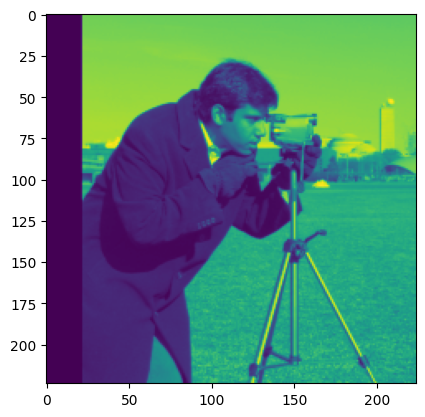

In [33]:
import matplotlib.pyplot as plt
plt.imshow(mockvideo_vid_data_tensor[10])

In [5]:
hr_feat_list = []
for frm_idx in range(mockvideo_vid_data_tensor.shape[0]):
    frm = mockvideo_vid_data_tensor[frm_idx, ...].permute(2, 0, 1) # (c, h, w)
    frm = torch.cat([frm for i in range(3)], dim=0)
    print("frm.shape: ", frm.shape)
    hr_feat = train_featup(cameraman=ImageFittingColorFeat(224, img_tensor=frm),
                 do_plot=False)
    print(hr_feat.shape)

    hr_feat_list.append(hr_feat)

mockvideo_hr_feat_2d = torch.stack(hr_feat_list, dim=0)
print(mockvideo_hr_feat_2d.shape)

frm.shape:  torch.Size([3, 224, 224])
self.img.shape:  torch.Size([3, 224, 224])
self.pixels.shape:  torch.Size([50176, 3])
self.combined_input_features.shape:  torch.Size([50176, 5])


C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\ImmersionLab/.cache\torch\hub\facebookresearch_dino_main


lr_feat_ground_truth_in_matrix.shape:  torch.Size([100, 384, 14, 14])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  tensor(19.6434, device='cuda:0', grad_fn=<MeanBackward0>)
Step 0, Total loss 19.643444



...

tensor(19.1463, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:33<00:04,  4.00s/it]

tensor(19.1414, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:37<00:04,  4.15s/it]


KeyboardInterrupt: 

In [5]:
print(mockvideo_hr_feat_2d.shape)

torch.Size([30, 384, 224, 224])


In [6]:
mockvideo_feat_data = mockvideo_hr_feat_2d.detach().cpu().permute(0, 2, 3, 1).numpy()
np.save(rf'{WORK_DIR}\data\mock_videos\mockvideo_feat_data.npy', 
        mockvideo_feat_data)


## Repeat for ultrasound example

In [4]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import torchvision.transforms.v2 as transforms
PATH = r"C:\data\ultrasound_db\musculoskeletal\dataset2\featup_demo"
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

def preprocess_to_vit_inference(image_size=(224, 224), crop_size=0.99, interpolation=transforms.InterpolationMode.LANCZOS, mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD):
    return transforms.Compose([
        transforms.Resize(image_size, interpolation=interpolation),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

def load_us_video(path, idx1=0, idx2=-1, step=1):
    df = pd.read_csv(os.path.join(path, 'tracking.csv'))
    im_files = list(df['frame_name'].drop_duplicates())
    vid_array = []
    for idx, im_file in enumerate(im_files[idx1:idx2:step]):
        frame =  preprocess_to_vit_inference()(Image.open(os.path.join(path, 'images', im_file)))
        vid_array.append(frame[None])
    vid_tensor = torch.cat(vid_array, dim=0)
    return vid_tensor

us_vid = load_us_video(PATH, idx1=15, idx2=-15, step=3)

C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
us_vid.shape

torch.Size([60, 3, 224, 224])

In [6]:
hr_feat_list = []
for frm_idx in range(us_vid.shape[0]):
    # frm = us_vid[frm_idx, ...].permute(2, 0, 1) # (c, h, w)
    # frm = torch.cat([frm for i in range(3)], dim=0)
    frm = us_vid[frm_idx]
    print("frm.shape: ", frm.shape)
    hr_feat = train_featup(cameraman=ImageFittingColorFeat(224, img_tensor=frm),
                 do_plot=False)
    print(hr_feat.shape)

    hr_feat_list.append(hr_feat)

us_hr_feat = torch.stack(hr_feat_list, dim=0)

frm.shape:  torch.Size([3, 224, 224])
self.img.shape:  torch.Size([3, 224, 224])
self.pixels.shape:  torch.Size([50176, 3])
self.combined_input_features.shape:  torch.Size([50176, 5])


C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\ImmersionLab/.cache\torch\hub\facebookresearch_dino_main


lr_feat_ground_truth_in_matrix.shape:  torch.Size([100, 384, 14, 14])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  tensor(20.2365, device='cuda:0', grad_fn=<MeanBackward0>)
Step 0, Total loss 20.236528



...

tensor(20.0203, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [01:26<00:10, 10.47s/it]

tensor(20.0194, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:37<00:00,  9.74s/it]

tensor(19.9509, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([384, 224, 224])


In [7]:
us_feat_data = us_hr_feat.detach().cpu().permute(0, 2, 3, 1).numpy()
np.save(rf'{WORK_DIR}\data\mock_videos\us_feat_data.npy', us_feat_data)